# Gestalt Segmentation Analysis: HDGMM DEPTH ABLATION COMPARISON

Compares two different depth ablation strategies against the baseline.

**COMPARISON:**
- **Baseline HDGMM**: Full depth information from depth estimator
- **Ablation 1 (Constant Depth)**: All depth values set to constant (no depth variation)
  - Uses depth-based segmentation for initialization
  - Model fits tight "pancake" distribution in Z
- **Ablation 2 (Z-Softened + Flow Init)**: Constant depth with Z variance added
  - Uses flow-based segmentation for initialization (threshold=0.05)
  - Z positions have Gaussian noise added (std ∝ median XY motion × 1.5)
  - Z motion also has noise added (std ∝ median XY motion × 0.75)
  - Simulates depth uncertainty without assuming access to depth estimate
- SegAnyMo & FlowSAM: Included for reference

**Key Question:** Does adding Z variance to simulate depth uncertainty improve ablation performance?

**Evaluation:** Probe-point sampling with NO skipping methodology at 96×96 resolution.

In [1]:
import numpy as np
import os
import json
from PIL import Image
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats
import jax.numpy as jnp
import jax

In [2]:
# Configuration
GESTALT_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/assets/from_thomas'
SEGANYMO_BASE_PATH = '/home/esli/SegAnyMo/gestalt_SegAnyMo_outputs'
HDGMM_BASELINE_PATH = '/home/esli/GenParticles_neural_stimulus/video_gestalt_masks'  # Baseline with full depth
HDGMM_ABLATION1_PATH = '/home/esli/GenParticles_neural_stimulus/video_gestalt_masks_rebuttal'  # Ablation 1: Constant depth
HDGMM_ABLATION2_PATH = '/home/esli/GenParticles_neural_stimulus/video_gestalt_masks_rebuttal_ablation_flow_init'  # Ablation 2: Z-softened + flow init
OUTPUT_DIR = '/home/esli/GenParticles_neural_stimulus/analysis_results_depth_ablation_comparison'  # Unique path

SCENES = [f'scene_{i:05d}' for i in range(20)]
TEXTURES = ['texture_00', 'texture_07', 'texture_13', 'texture_16', 'texture_21', 'texture_22', 'texture_25']
NUM_FRAMES = 6  # Changed from 5 to 6 to match rebuttal script
NUM_PROBES = 100
RANDOM_SEED = 42  # Global random seed for reproducibility

# Set global random seeds
np.random.seed(RANDOM_SEED)
jax.random.PRNGKey(RANDOM_SEED)  # Seed JAX random number generator

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Analyzing {len(SCENES)} scenes × {len(TEXTURES)} textures = {len(SCENES)*len(TEXTURES)} combinations")
print(f"Random seed: {RANDOM_SEED}")
print(f"\nHDGMM Baseline (full depth):          {HDGMM_BASELINE_PATH}")
print(f"HDGMM Ablation 1 (constant depth):    {HDGMM_ABLATION1_PATH}")
print(f"HDGMM Ablation 2 (Z-softened+flow):   {HDGMM_ABLATION2_PATH}")

Analyzing 20 scenes × 7 textures = 140 combinations
Random seed: 42

HDGMM Baseline (full depth):          /home/esli/GenParticles_neural_stimulus/video_gestalt_masks
HDGMM Ablation 1 (constant depth):    /home/esli/GenParticles_neural_stimulus/video_gestalt_masks_rebuttal
HDGMM Ablation 2 (Z-softened+flow):   /home/esli/GenParticles_neural_stimulus/video_gestalt_masks_rebuttal_ablation_flow_init


In [3]:
# Core helper functions

def load_ground_truth_mask(scene, frame_idx):
    """Load ground truth binary mask (1000×1000)"""
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, 'render_passes', 'masks', f'Image{frame_idx+1:04d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    if mask_img.ndim == 3:
        mask_img = mask_img[:, :, 0]
    return mask_img > 127

def load_seganymo_mask(scene, texture, frame_idx):
    """Load SegAnyMo mask (1000×1000)"""
    mask_file = os.path.join(SEGANYMO_BASE_PATH, f'{scene}_{texture}', 'sam2', 'initial_preds', 
                              'output_six_frame', f'{frame_idx:05d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    return mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img

def load_flowsam_mask(scene, texture, frame_idx):
    """Load FlowSAM mask (1000×1000), colored by detected objects"""
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam_matched_reprocessed', 
                              f'frame_{frame_idx:05d}_matched.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    return mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img

def load_hdgmm_mask_single_run(scene, texture, frame_idx, run_idx=0, ablation_type='baseline'):
    """
    Load HDGMM mask from single run (96×96)
    ablation_type: 'baseline', 'constant_depth', or '2d_only'
    """
    if ablation_type == 'baseline':
        base_path = HDGMM_BASELINE_PATH
    elif ablation_type == 'constant_depth':
        base_path = HDGMM_ABLATION1_PATH
    elif ablation_type == '2d_only':
        base_path = HDGMM_ABLATION2_PATH
    else:
        raise ValueError(f"Unknown ablation_type: {ablation_type}")
    
    path = os.path.join(base_path, scene, texture, f'run_{run_idx}', 'assignments.npz')
    if not os.path.exists(path):
        return None
    data = np.load(path, allow_pickle=True)
    if 'pixel_hyperblob_assignments' not in data or frame_idx >= len(data['pixel_hyperblob_assignments']):
        return None
    return data['pixel_hyperblob_assignments'][frame_idx].astype(np.int32)

def load_hdgmm_mask(scene, texture, frame_idx, num_runs=1, ablation_type='baseline'):
    """
    Load HDGMM mask averaged across runs using mode (96×96)
    ablation_type: 'baseline', 'constant_depth', or '2d_only'
    """
    masks = [load_hdgmm_mask_single_run(scene, texture, frame_idx, i, ablation_type) for i in range(num_runs)]
    masks = [m for m in masks if m is not None]
    if len(masks) == 0:
        return None
    if len(masks) == 1:
        return masks[0]
    masks_stack = np.stack(masks, axis=0)
    mode_mask, _ = stats.mode(masks_stack, axis=0, keepdims=False)
    return mode_mask.astype(np.int32)

In [4]:
# Core evaluation function

def evaluate_segmentation_NO_SKIPPING(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Evaluate segmentation using probe-point sampling. NO SKIPPING - all segment IDs treated equally.
    Returns: (mean_accuracy, probe_accuracies)
    """
    if true_mask is None or predicted_mask is None:
        return None, []
    
    # Resize predicted mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return 0.0, []
    
    if random_seed is not None:
        np.random.seed(random_seed)
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    probe_accuracies = []
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        segment_mask = (pred_flat == segment_id)
        accuracy = np.mean(true_flat == segment_mask)
        probe_accuracies.append(accuracy)
    
    return np.mean(probe_accuracies), probe_accuracies

def compute_binary_metrics(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Compute precision, recall, F1, false positive rate, false negative rate, and Jaccard index.
    Uses probe-based methodology: sample a probe from ground truth object, then evaluate
    the predicted segment that the probe lands in.
    
    Returns: dict with precision, recall, f1, fpr, fnr, jaccard (all averaged across probes)
    """
    if true_mask is None or predicted_mask is None:
        return None
    
    # Resize predicted mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'fpr': 0.0, 'fnr': 1.0, 'jaccard': 0.0}
    
    if random_seed is not None:
        np.random.seed(random_seed)
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    precisions = []
    recalls = []
    f1s = []
    fprs = []
    fnrs = []
    jaccards = []
    
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        pred_segment_mask = (pred_flat == segment_id)
        
        # Compute confusion matrix elements
        tp = np.sum(pred_segment_mask & true_flat)
        fp = np.sum(pred_segment_mask & ~true_flat)
        fn = np.sum(~pred_segment_mask & true_flat)
        tn = np.sum(~pred_segment_mask & ~true_flat)
        
        # Precision: TP / (TP + FP)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        
        # Recall: TP / (TP + FN)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        # F1: 2 * (precision * recall) / (precision + recall)
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # False Positive Rate: FP / (FP + TN)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        
        # False Negative Rate: FN / (FN + TP)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        
        # Jaccard Index (IoU): TP / (TP + FP + FN)
        jaccard = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        fprs.append(fpr)
        fnrs.append(fnr)
        jaccards.append(jaccard)
    
    return {
        'precision': np.mean(precisions),
        'recall': np.mean(recalls),
        'f1': np.mean(f1s),
        'fpr': np.mean(fprs),
        'fnr': np.mean(fnrs),
        'jaccard': np.mean(jaccards)
    }

# Core evaluation function

def evaluate_segmentation_NO_SKIPPING(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Evaluate segmentation using probe-point sampling. NO SKIPPING - all segment IDs treated equally.
    Returns: (mean_accuracy, probe_accuracies)
    """
    if true_mask is None or predicted_mask is None:
        return None, []
    
    # Resize predicted mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return 0.0, []
    
    if random_seed is not None:
        np.random.seed(random_seed)
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    probe_accuracies = []
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        segment_mask = (pred_flat == segment_id)
        accuracy = np.mean(true_flat == segment_mask)
        probe_accuracies.append(accuracy)
    
    return np.mean(probe_accuracies), probe_accuracies

def compute_binary_metrics(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Compute precision, recall, F1, false positive rate, false negative rate, and Jaccard index.
    Uses probe-based methodology: sample a probe from ground truth object, then evaluate
    the predicted segment that the probe lands in.
    
    Returns: dict with precision, recall, f1, fpr, fnr, jaccard (all averaged across probes)
    """
    if true_mask is None or predicted_mask is None:
        return None
    
    # Resize predicted mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'fpr': 0.0, 'fnr': 1.0, 'jaccard': 0.0}
    
    if random_seed is not None:
        np.random.seed(random_seed)
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    precisions = []
    recalls = []
    f1s = []
    fprs = []
    fnrs = []
    jaccards = []
    
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        pred_segment_mask = (pred_flat == segment_id)
        
        # Compute confusion matrix elements
        tp = np.sum(pred_segment_mask & true_flat)
        fp = np.sum(pred_segment_mask & ~true_flat)
        fn = np.sum(~pred_segment_mask & true_flat)
        tn = np.sum(~pred_segment_mask & ~true_flat)
        
        # Precision: TP / (TP + FP)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        
        # Recall: TP / (TP + FN)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        # F1: 2 * (precision * recall) / (precision + recall)
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # False Positive Rate: FP / (FP + TN)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        
        # False Negative Rate: FN / (FN + TP)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        
        # Jaccard Index (IoU): TP / (TP + FP + FN)
        jaccard = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        fprs.append(fpr)
        fnrs.append(fnr)
        jaccards.append(jaccard)
    
    return {
        'precision': np.mean(precisions),
        'recall': np.mean(recalls),
        'f1': np.mean(f1s),
        'fpr': np.mean(fprs),
        'fnr': np.mean(fnrs),
        'jaccard': np.mean(jaccards)
    }

def evaluate_all_methods(scene, texture, frame_idx, num_probes=100, random_seed=RANDOM_SEED):
    """
    Evaluate SegAnyMo, FlowSAM, HDGMM Baseline, and both HDGMM Ablations on single frame.
    All methods evaluated at HDGMM native resolution (96x96) for fair comparison.
    Uses deterministic seeding based on scene, texture, and frame for reproducibility.
    """
    true_mask = load_ground_truth_mask(scene, frame_idx)
    if true_mask is None:
        return None
    
    # Create deterministic seed for this specific evaluation
    scene_num = int(scene.split('_')[1])
    texture_num = int(texture.split('_')[1])
    eval_seed = random_seed + scene_num * 1000 + texture_num * 10 + frame_idx
    
    # Get HDGMM masks to determine target resolution
    hdgmm_baseline_mask = load_hdgmm_mask(scene, texture, frame_idx, num_runs=1, ablation_type='baseline')
    hdgmm_ablation1_mask = load_hdgmm_mask(scene, texture, frame_idx, num_runs=1, ablation_type='constant_depth')
    hdgmm_ablation2_mask = load_hdgmm_mask(scene, texture, frame_idx, num_runs=1, ablation_type='2d_only')
    
    if hdgmm_baseline_mask is not None:
        target_size = hdgmm_baseline_mask.shape[0]
    elif hdgmm_ablation1_mask is not None:
        target_size = hdgmm_ablation1_mask.shape[0]
    elif hdgmm_ablation2_mask is not None:
        target_size = hdgmm_ablation2_mask.shape[0]
    else:
        # Fallback: use 96x96 if HDGMM mask not available
        target_size = 96
    
    zoom_factors = (target_size / true_mask.shape[0], target_size / true_mask.shape[1])
    true_mask_resized = zoom(true_mask.astype(float), zoom_factors, order=0) > 0.5
    
    # SegAnyMo - downsample to target resolution
    seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
    if seganymo_mask is not None:
        zoom_factors = (target_size / seganymo_mask.shape[0], target_size / seganymo_mask.shape[1])
        seganymo_mask_resized = zoom(seganymo_mask.astype(float), zoom_factors, order=0).astype(int)
        seg_acc, seg_probes = evaluate_segmentation_NO_SKIPPING(true_mask_resized, seganymo_mask_resized, 
                                                                 num_probes, eval_seed)
        seg_metrics = compute_binary_metrics(true_mask_resized, seganymo_mask_resized, 
                                             num_probes, eval_seed + 1)
    else:
        seg_acc, seg_probes = None, []
        seg_metrics = None
    
    # FlowSAM - downsample to target resolution
    flowsam_mask = load_flowsam_mask(scene, texture, frame_idx)
    if flowsam_mask is not None:
        zoom_factors = (target_size / flowsam_mask.shape[0], target_size / flowsam_mask.shape[1])
        flowsam_mask_resized = zoom(flowsam_mask.astype(float), zoom_factors, order=0).astype(int)
        flowsam_acc, flowsam_probes = evaluate_segmentation_NO_SKIPPING(true_mask_resized, flowsam_mask_resized, 
                                                                         num_probes, eval_seed + 2)
        flowsam_metrics = compute_binary_metrics(true_mask_resized, flowsam_mask_resized, 
                                                 num_probes, eval_seed + 3)
    else:
        flowsam_acc, flowsam_probes = None, []
        flowsam_metrics = None
    
    # HDGMM Baseline (with full depth)
    if hdgmm_baseline_mask is not None:
        hdgmm_baseline_acc, hdgmm_baseline_probes = evaluate_segmentation_NO_SKIPPING(
            true_mask_resized, hdgmm_baseline_mask, num_probes, eval_seed + 4)
        hdgmm_baseline_metrics = compute_binary_metrics(true_mask_resized, hdgmm_baseline_mask, 
                                                        num_probes, eval_seed + 5)
    else:
        hdgmm_baseline_acc, hdgmm_baseline_probes = None, []
        hdgmm_baseline_metrics = None
    
    # HDGMM Ablation 1 (constant depth)
    if hdgmm_ablation1_mask is not None:
        hdgmm_ablation1_acc, hdgmm_ablation1_probes = evaluate_segmentation_NO_SKIPPING(
            true_mask_resized, hdgmm_ablation1_mask, num_probes, eval_seed + 6)
        hdgmm_ablation1_metrics = compute_binary_metrics(true_mask_resized, hdgmm_ablation1_mask, 
                                                         num_probes, eval_seed + 7)
    else:
        hdgmm_ablation1_acc, hdgmm_ablation1_probes = None, []
        hdgmm_ablation1_metrics = None
    
    # HDGMM Ablation 2 (2D only)
    if hdgmm_ablation2_mask is not None:
        hdgmm_ablation2_acc, hdgmm_ablation2_probes = evaluate_segmentation_NO_SKIPPING(
            true_mask_resized, hdgmm_ablation2_mask, num_probes, eval_seed + 8)
        hdgmm_ablation2_metrics = compute_binary_metrics(true_mask_resized, hdgmm_ablation2_mask, 
                                                         num_probes, eval_seed + 9)
    else:
        hdgmm_ablation2_acc, hdgmm_ablation2_probes = None, []
        hdgmm_ablation2_metrics = None
    
    return {
        'seganymo_acc': seg_acc,
        'flowsam_acc': flowsam_acc,
        'hdgmm_baseline_acc': hdgmm_baseline_acc,
        'hdgmm_ablation1_acc': hdgmm_ablation1_acc,
        'hdgmm_ablation2_acc': hdgmm_ablation2_acc,
        'seganymo_probes': seg_probes,
        'flowsam_probes': flowsam_probes,
        'hdgmm_baseline_probes': hdgmm_baseline_probes,
        'hdgmm_ablation1_probes': hdgmm_ablation1_probes,
        'hdgmm_ablation2_probes': hdgmm_ablation2_probes,
        'seganymo_metrics': seg_metrics,
        'flowsam_metrics': flowsam_metrics,
        'hdgmm_baseline_metrics': hdgmm_baseline_metrics,
        'hdgmm_ablation1_metrics': hdgmm_ablation1_metrics,
        'hdgmm_ablation2_metrics': hdgmm_ablation2_metrics
    }

In [5]:
# Variance analysis functions

def analyze_categorical_variance(scene, texture, run_idx=0, exclude_background_uncertainty=True, use_baseline=True):
    """
    Compute per-pixel categorical variance from hyperblob sampling.
    If exclude_background_uncertainty=True, collapses all background hyperblobs into one category.
    Returns: (pixel_variances, mean_variance, spatial_variance_map)
    """
    base_path = HDGMM_BASELINE_PATH if use_baseline else HDGMM_ABLATION_PATH
    path = os.path.join(base_path, scene, texture, f'run_{run_idx}', 'assignments.npz')
    if not os.path.exists(path):
        return None, None, None
    
    data = np.load(path, allow_pickle=True)
    counts = data['hyperblob_sample_counts']  # (frames, H, W, num_categories)
    
    if exclude_background_uncertainty:
        roi_hyperblob_ids = data['roi_hyperblob_ids']  # (frames,)
        modified_counts = np.zeros(counts.shape[:3] + (2,))  # (frames, H, W, 2): [object, background]
        
        for frame_idx in range(len(roi_hyperblob_ids)):
            roi_id = roi_hyperblob_ids[frame_idx]
            modified_counts[frame_idx, :, :, 0] = counts[frame_idx, :, :, roi_id]
            for cat_idx in range(counts.shape[3]):
                if cat_idx != roi_id:
                    modified_counts[frame_idx, :, :, 1] += counts[frame_idx, :, :, cat_idx]
        counts = modified_counts
    
    counts_jax = jnp.array(counts)
    probs = counts_jax / jnp.sum(counts_jax, axis=-1, keepdims=True)
    pixel_variances = jnp.sum(probs * (1.0 - probs), axis=-1)  # Categorical variance
    
    pixel_variances = np.array(pixel_variances)
    return pixel_variances, np.mean(pixel_variances), np.mean(pixel_variances, axis=0)

def compute_inter_run_variance(scene, texture, frame_idx, num_runs=1, use_baseline=True):
    """
    Compute per-pixel consistency across HDGMM runs.
    Returns: (agreement_map, entropy_map, mean_agreement)
    """
    masks = [load_hdgmm_mask_single_run(scene, texture, frame_idx, i, use_baseline) for i in range(num_runs)]
    masks = [m for m in masks if m is not None]
    if len(masks) < 2:
        return None, None, None
    
    masks_stack = np.stack(masks, axis=0)
    agreement_map = np.zeros(masks_stack.shape[1:])
    entropy_map = np.zeros(masks_stack.shape[1:])
    
    for i in range(masks_stack.shape[1]):
        for j in range(masks_stack.shape[2]):
            pixel_values = masks_stack[:, i, j]
            unique, counts = np.unique(pixel_values, return_counts=True)
            agreement_map[i, j] = np.max(counts) / len(pixel_values)
            probs = counts / len(pixel_values)
            entropy_map[i, j] = -np.sum(probs * np.log2(probs + 1e-10))
    
    return agreement_map, entropy_map, np.mean(agreement_map)

In [7]:
# Main processing loop

existing_combinations = []
for scene in SCENES:
    for texture in TEXTURES:
        seg_dir = os.path.join(SEGANYMO_BASE_PATH, f'{scene}_{texture}', 'sam2', 'initial_preds', 'output_six_frame')
        flowsam_dir = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam_matched')
        hdgmm_baseline_dir = os.path.join(HDGMM_BASELINE_PATH, scene, texture)
        hdgmm_ablation_dir = os.path.join(HDGMM_ABLATION2_PATH, scene, texture)
        has_baseline = any(os.path.exists(os.path.join(hdgmm_baseline_dir, f'run_{i}')) for i in range(5))
        has_ablation = os.path.exists(os.path.join(hdgmm_ablation_dir, 'run_0'))
        if os.path.exists(seg_dir) or os.path.exists(flowsam_dir) or has_baseline or has_ablation:
            existing_combinations.append((scene, texture))

print(f"Processing {len(existing_combinations)} combinations\n")

all_results = []
for scene, texture in existing_combinations:
    print(f"Processing {scene} - {texture}")
    
    seganymo_frames = []
    flowsam_frames = []
    hdgmm_baseline_frames = []
    hdgmm_ablation1_frames = []
    hdgmm_ablation2_frames = []
    
    seganymo_metrics_frames = []
    flowsam_metrics_frames = []
    hdgmm_baseline_metrics_frames = []
    hdgmm_ablation1_metrics_frames = []
    hdgmm_ablation2_metrics_frames = []
    
    for frame_idx in range(NUM_FRAMES):
        result = evaluate_all_methods(scene, texture, frame_idx, NUM_PROBES)
        if result is None:
            seganymo_frames.append(None)
            flowsam_frames.append(None)
            hdgmm_baseline_frames.append(None)
            hdgmm_ablation1_frames.append(None)
            hdgmm_ablation2_frames.append(None)
            seganymo_metrics_frames.append(None)
            flowsam_metrics_frames.append(None)
            hdgmm_baseline_metrics_frames.append(None)
            hdgmm_ablation1_metrics_frames.append(None)
            hdgmm_ablation2_metrics_frames.append(None)
        else:
            seganymo_frames.append(result['seganymo_acc'])
            flowsam_frames.append(result['flowsam_acc'])
            hdgmm_baseline_frames.append(result['hdgmm_baseline_acc'])
            hdgmm_ablation1_frames.append(result['hdgmm_ablation1_acc'])
            hdgmm_ablation2_frames.append(result['hdgmm_ablation2_acc'])
            seganymo_metrics_frames.append(result['seganymo_metrics'])
            flowsam_metrics_frames.append(result['flowsam_metrics'])
            hdgmm_baseline_metrics_frames.append(result['hdgmm_baseline_metrics'])
            hdgmm_ablation1_metrics_frames.append(result['hdgmm_ablation1_metrics'])
            hdgmm_ablation2_metrics_frames.append(result['hdgmm_ablation2_metrics'])
    
    seg_valid = [a for a in seganymo_frames if a is not None]
    flowsam_valid = [a for a in flowsam_frames if a is not None]
    hdgmm_baseline_valid = [a for a in hdgmm_baseline_frames if a is not None]
    hdgmm_ablation1_valid = [a for a in hdgmm_ablation1_frames if a is not None]
    hdgmm_ablation2_valid = [a for a in hdgmm_ablation2_frames if a is not None]
    
    # Average metrics across frames
    def average_metrics(metrics_list):
        valid = [m for m in metrics_list if m is not None]
        if not valid:
            return None
        return {
            'precision': np.mean([m['precision'] for m in valid]),
            'recall': np.mean([m['recall'] for m in valid]),
            'f1': np.mean([m['f1'] for m in valid]),
            'fpr': np.mean([m['fpr'] for m in valid]),
            'fnr': np.mean([m['fnr'] for m in valid]),
            'jaccard': np.mean([m['jaccard'] for m in valid])
        }
    
    all_results.append({
        'scene': scene,
        'texture': texture,
        'seganymo_mean': np.mean(seg_valid) if seg_valid else None,
        'seganymo_std': np.std(seg_valid) if seg_valid else None,
        'flowsam_mean': np.mean(flowsam_valid) if flowsam_valid else None,
        'flowsam_std': np.std(flowsam_valid) if flowsam_valid else None,
        'hdgmm_baseline_mean': np.mean(hdgmm_baseline_valid) if hdgmm_baseline_valid else None,
        'hdgmm_baseline_std': np.std(hdgmm_baseline_valid) if hdgmm_baseline_valid else None,
        'hdgmm_ablation1_mean': np.mean(hdgmm_ablation1_valid) if hdgmm_ablation1_valid else None,
        'hdgmm_ablation1_std': np.std(hdgmm_ablation1_valid) if hdgmm_ablation1_valid else None,
        'hdgmm_ablation2_mean': np.mean(hdgmm_ablation2_valid) if hdgmm_ablation2_valid else None,
        'hdgmm_ablation2_std': np.std(hdgmm_ablation2_valid) if hdgmm_ablation2_valid else None,
        'seganymo_frames': seganymo_frames,
        'flowsam_frames': flowsam_frames,
        'hdgmm_baseline_frames': hdgmm_baseline_frames,
        'hdgmm_ablation1_frames': hdgmm_ablation1_frames,
        'hdgmm_ablation2_frames': hdgmm_ablation2_frames,
        'seganymo_metrics': average_metrics(seganymo_metrics_frames),
        'flowsam_metrics': average_metrics(flowsam_metrics_frames),
        'hdgmm_baseline_metrics': average_metrics(hdgmm_baseline_metrics_frames),
        'hdgmm_ablation1_metrics': average_metrics(hdgmm_ablation1_metrics_frames),
        'hdgmm_ablation2_metrics': average_metrics(hdgmm_ablation2_metrics_frames)
    })

# Save results
with open(os.path.join(OUTPUT_DIR, 'all_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else x)

print(f"\nCompleted. Results saved to {OUTPUT_DIR}")

Processing 140 combinations

Processing scene_00000 - texture_00
Processing scene_00000 - texture_07
Processing scene_00000 - texture_13
Processing scene_00000 - texture_16
Processing scene_00000 - texture_21
Processing scene_00000 - texture_22
Processing scene_00000 - texture_25
Processing scene_00001 - texture_00
Processing scene_00001 - texture_07
Processing scene_00001 - texture_13
Processing scene_00001 - texture_16
Processing scene_00001 - texture_21
Processing scene_00001 - texture_22
Processing scene_00001 - texture_25
Processing scene_00002 - texture_00
Processing scene_00002 - texture_07
Processing scene_00002 - texture_13
Processing scene_00002 - texture_16
Processing scene_00002 - texture_21
Processing scene_00002 - texture_22
Processing scene_00002 - texture_25
Processing scene_00003 - texture_00
Processing scene_00003 - texture_07
Processing scene_00003 - texture_13
Processing scene_00003 - texture_16
Processing scene_00003 - texture_21
Processing scene_00003 - texture_22

In [8]:
# Summary statistics

seganymo_all = [r['seganymo_mean'] for r in all_results if r['seganymo_mean'] is not None]
flowsam_all = [r['flowsam_mean'] for r in all_results if r['flowsam_mean'] is not None]
hdgmm_baseline_all = [r['hdgmm_baseline_mean'] for r in all_results if r['hdgmm_baseline_mean'] is not None]
hdgmm_ablation1_all = [r['hdgmm_ablation1_mean'] for r in all_results if r['hdgmm_ablation1_mean'] is not None]
hdgmm_ablation2_all = [r['hdgmm_ablation2_mean'] for r in all_results if r['hdgmm_ablation2_mean'] is not None]

print("\n" + "="*70)
print("SUMMARY STATISTICS - ACCURACY")
print("="*70)

print(f"\nSegAnyMo (N={len(seganymo_all)}):")
print(f"  Mean: {np.mean(seganymo_all):.4f} ± {np.std(seganymo_all):.4f}")
print(f"  Range: [{np.min(seganymo_all):.4f}, {np.max(seganymo_all):.4f}]")

print(f"\nFlowSAM (N={len(flowsam_all)}):")
print(f"  Mean: {np.mean(flowsam_all):.4f} ± {np.std(flowsam_all):.4f}")
print(f"  Range: [{np.min(flowsam_all):.4f}, {np.max(flowsam_all):.4f}]")

print(f"\nHDGMM Baseline [FULL DEPTH] (N={len(hdgmm_baseline_all)}):")
print(f"  Mean: {np.mean(hdgmm_baseline_all):.4f} ± {np.std(hdgmm_baseline_all):.4f}")
print(f"  Range: [{np.min(hdgmm_baseline_all):.4f}, {np.max(hdgmm_baseline_all):.4f}]")

print(f"\nHDGMM Ablation 1 [CONSTANT DEPTH] (N={len(hdgmm_ablation1_all)}):")
print(f"  Mean: {np.mean(hdgmm_ablation1_all):.4f} ± {np.std(hdgmm_ablation1_all):.4f}")
print(f"  Range: [{np.min(hdgmm_ablation1_all):.4f}, {np.max(hdgmm_ablation1_all):.4f}]")

print(f"\nHDGMM Ablation 2 [Z-SOFTENED] (N={len(hdgmm_ablation2_all)}):")
print(f"  Mean: {np.mean(hdgmm_ablation2_all):.4f} ± {np.std(hdgmm_ablation2_all):.4f}")
print(f"  Range: [{np.min(hdgmm_ablation2_all):.4f}, {np.max(hdgmm_ablation2_all):.4f}]")

# Precision, Recall, F1, FPR, FNR, Jaccard statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS - PRECISION, RECALL, F1, JACCARD")
print("="*70)

def print_metrics_summary(method_name, results_key):
    metrics_list = [r[results_key] for r in all_results if r[results_key] is not None]
    if not metrics_list:
        print(f"\n{method_name}: No data")
        return
    
    precision_vals = [m['precision'] for m in metrics_list]
    recall_vals = [m['recall'] for m in metrics_list]
    f1_vals = [m['f1'] for m in metrics_list]
    fpr_vals = [m['fpr'] for m in metrics_list]
    fnr_vals = [m['fnr'] for m in metrics_list]
    jaccard_vals = [m['jaccard'] for m in metrics_list]
    
    print(f"\n{method_name} (N={len(metrics_list)}):")
    print(f"  Precision: {np.mean(precision_vals):.4f} ± {np.std(precision_vals):.4f}")
    print(f"  Recall:    {np.mean(recall_vals):.4f} ± {np.std(recall_vals):.4f}")
    print(f"  F1:        {np.mean(f1_vals):.4f} ± {np.std(f1_vals):.4f}")
    print(f"  Jaccard:   {np.mean(jaccard_vals):.4f} ± {np.std(jaccard_vals):.4f}")
    print(f"  FPR:       {np.mean(fpr_vals):.4f} ± {np.std(fpr_vals):.4f}")
    print(f"  FNR:       {np.mean(fnr_vals):.4f} ± {np.std(fnr_vals):.4f}")

print_metrics_summary("SegAnyMo", "seganymo_metrics")
print_metrics_summary("FlowSAM", "flowsam_metrics")
print_metrics_summary("HDGMM Baseline [FULL DEPTH]", "hdgmm_baseline_metrics")
print_metrics_summary("HDGMM Ablation 1 [CONSTANT DEPTH]", "hdgmm_ablation1_metrics")
print_metrics_summary("HDGMM Ablation 2 [Z-SOFTENED]", "hdgmm_ablation2_metrics")

# Ablation comparisons (key results!)
paired_baseline = [r['hdgmm_baseline_mean'] for r in all_results if r['hdgmm_baseline_mean'] and r['hdgmm_ablation1_mean']]
paired_ablation1 = [r['hdgmm_ablation1_mean'] for r in all_results if r['hdgmm_baseline_mean'] and r['hdgmm_ablation1_mean']]

if paired_baseline and paired_ablation1:
    print(f"\n{'='*70}")
    print(f"ABLATION 1: BASELINE vs CONSTANT DEPTH (N={len(paired_baseline)})")
    print(f"{'='*70}")
    
    diff_ablation1 = np.array(paired_baseline) - np.array(paired_ablation1)
    t_stat, p_value = stats.ttest_rel(paired_baseline, paired_ablation1)
    print(f"\nBaseline (full depth) vs Ablation 1 (constant depth):")
    print(f"  Mean accuracy difference: {np.mean(diff_ablation1):.4f} ± {np.std(diff_ablation1):.4f}")
    print(f"  Baseline wins: {np.sum(diff_ablation1 > 0)}, Ablation wins: {np.sum(diff_ablation1 < 0)}")
    print(f"  t-test: t={t_stat:.4f}, p={p_value:.6f}")
    print(f"\n  Performance drop: {np.mean(diff_ablation1):.4f} ({np.mean(diff_ablation1)/np.mean(paired_baseline)*100:.2f}%)")

paired_baseline2 = [r['hdgmm_baseline_mean'] for r in all_results if r['hdgmm_baseline_mean'] and r['hdgmm_ablation2_mean']]
paired_ablation2 = [r['hdgmm_ablation2_mean'] for r in all_results if r['hdgmm_baseline_mean'] and r['hdgmm_ablation2_mean']]

if paired_baseline2 and paired_ablation2:
    print(f"\n{'='*70}")
    print(f"ABLATION 2: BASELINE vs Z-SOFTENED (N={len(paired_baseline2)})")
    print(f"{'='*70}")
    
    diff_ablation2 = np.array(paired_baseline2) - np.array(paired_ablation2)
    t_stat2, p_value2 = stats.ttest_rel(paired_baseline2, paired_ablation2)
    print(f"\nBaseline (full depth) vs Ablation 2 (Z-softened):")
    print(f"  Mean accuracy difference: {np.mean(diff_ablation2):.4f} ± {np.std(diff_ablation2):.4f}")
    print(f"  Baseline wins: {np.sum(diff_ablation2 > 0)}, Ablation wins: {np.sum(diff_ablation2 < 0)}")
    print(f"  t-test: t={t_stat2:.4f}, p={p_value2:.6f}")
    print(f"\n  Performance drop: {np.mean(diff_ablation2):.4f} ({np.mean(diff_ablation2)/np.mean(paired_baseline2)*100:.2f}%)")

# Compare the two ablations
paired_abl1 = [r['hdgmm_ablation1_mean'] for r in all_results if r['hdgmm_ablation1_mean'] and r['hdgmm_ablation2_mean']]
paired_abl2 = [r['hdgmm_ablation2_mean'] for r in all_results if r['hdgmm_ablation1_mean'] and r['hdgmm_ablation2_mean']]

if paired_abl1 and paired_abl2:
    print(f"\n{'='*70}")
    print(f"ABLATIONS COMPARISON: CONSTANT DEPTH vs Z-SOFTENED (N={len(paired_abl1)})")
    print(f"{'='*70}")
    
    diff_ablations = np.array(paired_abl1) - np.array(paired_abl2)
    t_stat3, p_value3 = stats.ttest_rel(paired_abl1, paired_abl2)
    print(f"\nAblation 1 (constant depth) vs Ablation 2 (Z-softened):")
    print(f"  Mean accuracy difference: {np.mean(diff_ablations):.4f} ± {np.std(diff_ablations):.4f}")
    print(f"  Ablation 1 wins: {np.sum(diff_ablations > 0)}, Ablation 2 wins: {np.sum(diff_ablations < 0)}")
    print(f"  t-test: t={t_stat3:.4f}, p={p_value3:.6f}")

# Save summary
def metrics_to_dict(method_key):
    metrics_list = [r[method_key] for r in all_results if r[method_key] is not None]
    if not metrics_list:
        return None
    return {
        'precision': {'mean': float(np.mean([m['precision'] for m in metrics_list])),
                     'std': float(np.std([m['precision'] for m in metrics_list]))},
        'recall': {'mean': float(np.mean([m['recall'] for m in metrics_list])),
                  'std': float(np.std([m['recall'] for m in metrics_list]))},
        'f1': {'mean': float(np.mean([m['f1'] for m in metrics_list])),
              'std': float(np.std([m['f1'] for m in metrics_list]))},
        'jaccard': {'mean': float(np.mean([m['jaccard'] for m in metrics_list])),
                   'std': float(np.std([m['jaccard'] for m in metrics_list]))},
        'fpr': {'mean': float(np.mean([m['fpr'] for m in metrics_list])),
               'std': float(np.std([m['fpr'] for m in metrics_list]))},
        'fnr': {'mean': float(np.mean([m['fnr'] for m in metrics_list])),
               'std': float(np.std([m['fnr'] for m in metrics_list]))}
    }

summary = {
    'seganymo': {
        'n': len(seganymo_all), 
        'accuracy': {'mean': float(np.mean(seganymo_all)), 'std': float(np.std(seganymo_all))},
        'metrics': metrics_to_dict('seganymo_metrics')
    },
    'flowsam': {
        'n': len(flowsam_all), 
        'accuracy': {'mean': float(np.mean(flowsam_all)), 'std': float(np.std(flowsam_all))},
        'metrics': metrics_to_dict('flowsam_metrics')
    },
    'hdgmm_baseline': {
        'n': len(hdgmm_baseline_all), 
        'accuracy': {'mean': float(np.mean(hdgmm_baseline_all)), 'std': float(np.std(hdgmm_baseline_all))},
        'metrics': metrics_to_dict('hdgmm_baseline_metrics')
    },
    'hdgmm_ablation1': {
        'n': len(hdgmm_ablation1_all), 
        'accuracy': {'mean': float(np.mean(hdgmm_ablation1_all)), 'std': float(np.std(hdgmm_ablation1_all))},
        'metrics': metrics_to_dict('hdgmm_ablation1_metrics')
    },
    'hdgmm_ablation2': {
        'n': len(hdgmm_ablation2_all), 
        'accuracy': {'mean': float(np.mean(hdgmm_ablation2_all)), 'std': float(np.std(hdgmm_ablation2_all))},
        'metrics': metrics_to_dict('hdgmm_ablation2_metrics')
    },
    'ablation_comparisons': {
        'baseline_vs_ablation1': {
            'n': len(paired_baseline) if paired_baseline else 0,
            'mean_diff': float(np.mean(diff_ablation1)) if paired_baseline else None,
            'std_diff': float(np.std(diff_ablation1)) if paired_baseline else None,
            't_stat': float(t_stat) if paired_baseline else None,
            'p_value': float(p_value) if paired_baseline else None
        },
        'baseline_vs_ablation2': {
            'n': len(paired_baseline2) if paired_baseline2 else 0,
            'mean_diff': float(np.mean(diff_ablation2)) if paired_baseline2 else None,
            'std_diff': float(np.std(diff_ablation2)) if paired_baseline2 else None,
            't_stat': float(t_stat2) if paired_baseline2 else None,
            'p_value': float(p_value2) if paired_baseline2 else None
        },
        'ablation1_vs_ablation2': {
            'n': len(paired_abl1) if paired_abl1 else 0,
            'mean_diff': float(np.mean(diff_ablations)) if paired_abl1 else None,
            'std_diff': float(np.std(diff_ablations)) if paired_abl1 else None,
            't_stat': float(t_stat3) if paired_abl1 else None,
            'p_value': float(p_value3) if paired_abl1 else None
        }
    }
}

# Save summary
with open(os.path.join(OUTPUT_DIR, 'summary_statistics.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nSummary statistics saved to {os.path.join(OUTPUT_DIR, 'summary_statistics.json')}")


SUMMARY STATISTICS - ACCURACY

SegAnyMo (N=140):
  Mean: 0.3246 ± 0.2872
  Range: [0.0631, 0.9721]

FlowSAM (N=140):
  Mean: 0.8660 ± 0.1024
  Range: [0.4268, 0.9878]

HDGMM Baseline [FULL DEPTH] (N=140):
  Mean: 0.9388 ± 0.0372
  Range: [0.8020, 0.9906]

HDGMM Ablation 1 [CONSTANT DEPTH] (N=140):
  Mean: 0.7788 ± 0.1499
  Range: [0.3644, 0.9902]

HDGMM Ablation 2 [Z-SOFTENED] (N=140):
  Mean: 0.8858 ± 0.1437
  Range: [0.3548, 0.9891]

SUMMARY STATISTICS - PRECISION, RECALL, F1, JACCARD

SegAnyMo (N=140):
  Precision: 0.3186 ± 0.2797
  Recall:    0.8822 ± 0.1707
  F1:        0.3527 ± 0.2428
  Jaccard:   0.2615 ± 0.2579
  FPR:       0.7606 ± 0.3413
  FNR:       0.1178 ± 0.1707

FlowSAM (N=140):
  Precision: 0.8184 ± 0.1210
  Recall:    0.7215 ± 0.1558
  F1:        0.7414 ± 0.1662
  Jaccard:   0.6672 ± 0.1982
  FPR:       0.1114 ± 0.1043
  FNR:       0.2785 ± 0.1558

HDGMM Baseline [FULL DEPTH] (N=140):
  Precision: 0.8084 ± 0.0993
  Recall:    0.8126 ± 0.1421
  F1:        0.7978 ± 0.11

In [ ]:
# Per-scene breakdown (Ablation comparison)

by_scene = defaultdict(lambda: {'baseline': [], 'ablation1': [], 'ablation2': []})
for r in all_results:
    if r['hdgmm_baseline_mean'] is not None:
        by_scene[r['scene']]['baseline'].append(r['hdgmm_baseline_mean'])
    if r['hdgmm_ablation1_mean'] is not None:
        by_scene[r['scene']]['ablation1'].append(r['hdgmm_ablation1_mean'])
    if r['hdgmm_ablation2_mean'] is not None:
        by_scene[r['scene']]['ablation2'].append(r['hdgmm_ablation2_mean'])

print("\n" + "="*95)
print("PER-SCENE BREAKDOWN: ABLATION COMPARISON")
print("="*95)
print(f"\n{'Scene':<15} {'N':>5} {'Baseline':>12} {'Abl1 (Const)':>14} {'Abl2 (Z-soft)':>14} {'Δ1':>8} {'Δ2':>8}")
print("-"*95)

scene_breakdown = []
for scene in sorted(by_scene.keys()):
    baseline = by_scene[scene]['baseline']
    ablation1 = by_scene[scene]['ablation1']
    ablation2 = by_scene[scene]['ablation2']
    
    if baseline:
        baseline_mean = np.mean(baseline)
        abl1_mean = np.mean(ablation1) if ablation1 else None
        abl2_mean = np.mean(ablation2) if ablation2 else None
        delta1 = baseline_mean - abl1_mean if abl1_mean else None
        delta2 = baseline_mean - abl2_mean if abl2_mean else None
        
        print(f"{scene:<15} {len(baseline):>5} {baseline_mean:>12.3f} "
              f"{abl1_mean:>14.3f} {abl2_mean:>12.3f} "
              f"{delta1:>8.3f} {delta2:>8.3f}")
        
        scene_breakdown.append({
            'scene': scene, 'n': len(baseline), 
            'baseline_mean': float(baseline_mean),
            'ablation1_mean': float(abl1_mean) if abl1_mean else None,
            'ablation2_mean': float(abl2_mean) if abl2_mean else None,
            'delta1': float(delta1) if delta1 else None,
            'delta2': float(delta2) if delta2 else None
        })

with open(os.path.join(OUTPUT_DIR, 'breakdown_by_scene.json'), 'w') as f:
    json.dump(scene_breakdown, f, indent=2)


PER-SCENE BREAKDOWN: ABLATION STUDY

Scene               N     Baseline (depth)  Ablation (no depth)          Δ
--------------------------------------------------------------------------------
scene_00000         7     0.951±0.031         0.837±0.093         0.114
scene_00001         7     0.930±0.047         0.739±0.143         0.191
scene_00002         7     0.917±0.027         0.813±0.074         0.104
scene_00003         7     0.923±0.028         0.710±0.167         0.214
scene_00004         7     0.932±0.042         0.718±0.185         0.214
scene_00005         7     0.953±0.028         0.853±0.147         0.100
scene_00006         7     0.950±0.023         0.783±0.117         0.168
scene_00007         7     0.921±0.037         0.771±0.124         0.150
scene_00008         7     0.923±0.042         0.761±0.090         0.161
scene_00009         7     0.941±0.030         0.802±0.084         0.139
scene_00010         7     0.936±0.056         0.708±0.147         0.228
scene_00011   

In [ ]:
# Per-texture breakdown (Ablation comparison)

by_texture = defaultdict(lambda: {'baseline': [], 'ablation1': [], 'ablation2': []})
for r in all_results:
    if r['hdgmm_baseline_mean'] is not None:
        by_texture[r['texture']]['baseline'].append(r['hdgmm_baseline_mean'])
    if r['hdgmm_ablation1_mean'] is not None:
        by_texture[r['texture']]['ablation1'].append(r['hdgmm_ablation1_mean'])
    if r['hdgmm_ablation2_mean'] is not None:
        by_texture[r['texture']]['ablation2'].append(r['hdgmm_ablation2_mean'])

print("\n" + "="*95)
print("PER-TEXTURE BREAKDOWN: ABLATION COMPARISON")
print("="*95)
print(f"\n{'Texture':<15} {'N':>5} {'Baseline':>12} {'Abl1 (Const)':>14} {'Abl2 (Z-soft)':>14} {'Δ1':>8} {'Δ2':>8}")
print("-"*95)

texture_breakdown = []
for texture in sorted(by_texture.keys()):
    baseline = by_texture[texture]['baseline']
    ablation1 = by_texture[texture]['ablation1']
    ablation2 = by_texture[texture]['ablation2']
    
    if baseline:
        baseline_mean = np.mean(baseline)
        abl1_mean = np.mean(ablation1) if ablation1 else None
        abl2_mean = np.mean(ablation2) if ablation2 else None
        delta1 = baseline_mean - abl1_mean if abl1_mean else None
        delta2 = baseline_mean - abl2_mean if abl2_mean else None
        
        print(f"{texture:<15} {len(baseline):>5} {baseline_mean:>12.3f} "
              f"{abl1_mean:>14.3f} {abl2_mean:>12.3f} "
              f"{delta1:>8.3f} {delta2:>8.3f}")
        
        texture_breakdown.append({
            'texture': texture, 'n': len(baseline), 
            'baseline_mean': float(baseline_mean),
            'ablation1_mean': float(abl1_mean) if abl1_mean else None,
            'ablation2_mean': float(abl2_mean) if abl2_mean else None,
            'delta1': float(delta1) if delta1 else None,
            'delta2': float(delta2) if delta2 else None
        })

with open(os.path.join(OUTPUT_DIR, 'breakdown_by_texture.json'), 'w') as f:
    json.dump(texture_breakdown, f, indent=2)


PER-TEXTURE BREAKDOWN: ABLATION STUDY

Texture             N     Baseline (depth)  Ablation (no depth)          Δ
--------------------------------------------------------------------------------
texture_00         20     0.953±0.030         0.754±0.139         0.199
texture_07         20     0.962±0.045         0.805±0.152         0.157
texture_13         20     0.940±0.029         0.852±0.153         0.089
texture_16         20     0.932±0.028         0.751±0.133         0.181
texture_21         20     0.929±0.025         0.693±0.154         0.236
texture_22         20     0.946±0.036         0.820±0.142         0.126
texture_25         20     0.909±0.036         0.777±0.115         0.132


In [ ]:
# Variance analysis (Ablation comparison)

print("\n" + "="*70)
print("VARIANCE ANALYSIS: Baseline vs Ablation (sample: first 10 combinations)")
print("="*70)

variance_results = []
for scene, texture in existing_combinations[:10]:
    for frame_idx in range(NUM_FRAMES):
        # Get accuracy for both baseline and ablation
        result = evaluate_all_methods(scene, texture, frame_idx, NUM_PROBES)
        
        if result and result['hdgmm_baseline_acc'] is not None and result['hdgmm_ablation_acc'] is not None:
            # Categorical variance for baseline
            pixel_vars_baseline, mean_cat_var_baseline, _ = analyze_categorical_variance(
                scene, texture, run_idx=0, use_baseline=True)
            
            # Categorical variance for ablation
            pixel_vars_ablation, mean_cat_var_ablation, _ = analyze_categorical_variance(
                scene, texture, run_idx=0, use_baseline=False)
            
            variance_results.append({
                'scene': scene,
                'texture': texture,
                'frame': frame_idx,
                'baseline_accuracy': result['hdgmm_baseline_acc'],
                'ablation_accuracy': result['hdgmm_ablation_acc'],
                'baseline_categorical_variance': mean_cat_var_baseline,
                'ablation_categorical_variance': mean_cat_var_ablation
            })

if variance_results:
    # Analyze variance differences
    baseline_accs = [r['baseline_accuracy'] for r in variance_results]
    ablation_accs = [r['ablation_accuracy'] for r in variance_results]
    
    baseline_vars = [r['baseline_categorical_variance'] for r in variance_results if r['baseline_categorical_variance'] is not None]
    ablation_vars = [r['ablation_categorical_variance'] for r in variance_results if r['ablation_categorical_variance'] is not None]
    
    print(f"\nAccuracy comparison (N={len(baseline_accs)}):")
    print(f"  Baseline (with depth):    {np.mean(baseline_accs):.4f} ± {np.std(baseline_accs):.4f}")
    print(f"  Ablation (no depth):      {np.mean(ablation_accs):.4f} ± {np.std(ablation_accs):.4f}")
    print(f"  Difference:               {np.mean(baseline_accs) - np.mean(ablation_accs):.4f}")
    
    if baseline_vars and ablation_vars:
        print(f"\nCategorical variance comparison:")
        print(f"  Baseline (with depth):    {np.mean(baseline_vars):.4f} ± {np.std(baseline_vars):.4f}")
        print(f"  Ablation (no depth):      {np.mean(ablation_vars):.4f} ± {np.std(ablation_vars):.4f}")
        print(f"  Difference:               {np.mean(ablation_vars) - np.mean(baseline_vars):.4f}")
        print(f"\n  Higher variance in ablation suggests more uncertainty without depth cues")
    
    with open(os.path.join(OUTPUT_DIR, 'variance_analysis.json'), 'w') as f:
        json.dump(variance_results, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else x)


VARIANCE ANALYSIS: Baseline vs Ablation (sample: first 10 combinations)

Accuracy comparison (N=50):
  Baseline (with depth):    0.9487 ± 0.0398
  Ablation (no depth):      0.7999 ± 0.1897
  Difference:               0.1488

Categorical variance comparison:
  Baseline (with depth):    0.0049 ± 0.0036
  Ablation (no depth):      0.0185 ± 0.0242
  Difference:               0.0136

  Higher variance in ablation suggests more uncertainty without depth cues


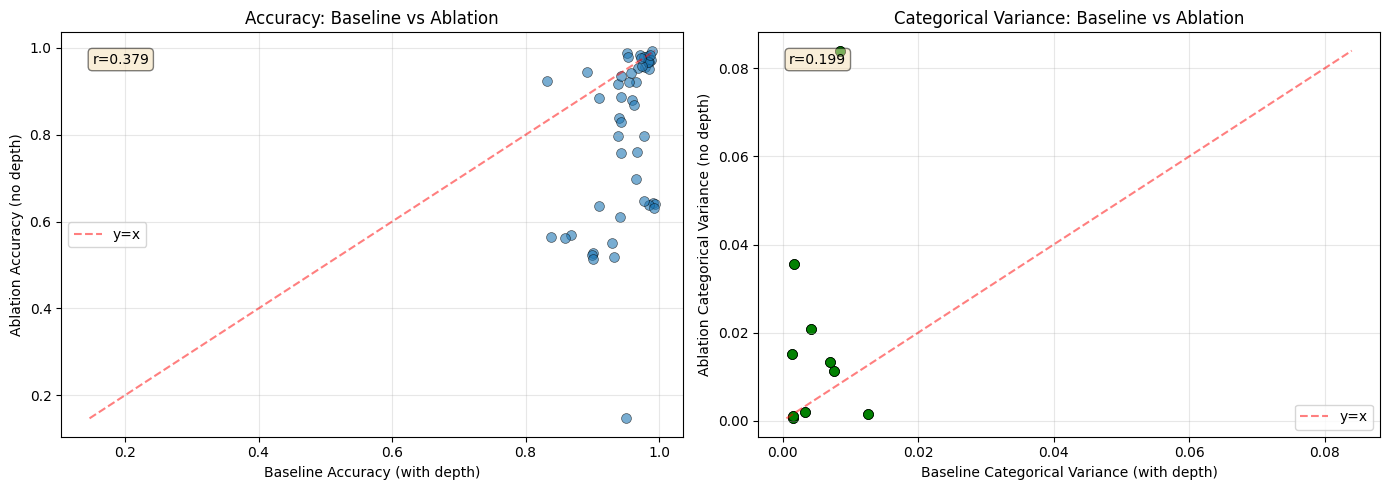


Ablation scatter plots saved to /home/esli/GenParticles_neural_stimulus/analysis_results_ablation_no_depth/ablation_scatter.png


In [ ]:
# Visualization: Ablation comparison scatter plot

if variance_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy: Baseline vs Ablation
    baseline_accs = [r['baseline_accuracy'] for r in variance_results]
    ablation_accs = [r['ablation_accuracy'] for r in variance_results]
    
    axes[0].scatter(baseline_accs, ablation_accs, alpha=0.6, edgecolor='k', linewidth=0.5, s=50)
    
    # Add diagonal line (y=x)
    min_val = min(min(baseline_accs), min(ablation_accs))
    max_val = max(max(baseline_accs), max(ablation_accs))
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    
    axes[0].set_xlabel('Baseline Accuracy (with depth)')
    axes[0].set_ylabel('Ablation Accuracy (no depth)')
    axes[0].set_title('Accuracy: Baseline vs Ablation')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    
    # Add correlation
    if len(baseline_accs) > 2:
        corr, _ = stats.pearsonr(baseline_accs, ablation_accs)
        axes[0].text(0.05, 0.95, f'r={corr:.3f}', transform=axes[0].transAxes, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Variance: Baseline vs Ablation
    baseline_vars = [r['baseline_categorical_variance'] for r in variance_results if r['baseline_categorical_variance'] is not None]
    ablation_vars = [r['ablation_categorical_variance'] for r in variance_results if r['ablation_categorical_variance'] is not None]
    
    if baseline_vars and ablation_vars:
        axes[1].scatter(baseline_vars, ablation_vars, alpha=0.6, edgecolor='k', linewidth=0.5, s=50, color='green')
        
        # Add diagonal line
        min_val = min(min(baseline_vars), min(ablation_vars))
        max_val = max(max(baseline_vars), max(ablation_vars))
        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
        
        axes[1].set_xlabel('Baseline Categorical Variance (with depth)')
        axes[1].set_ylabel('Ablation Categorical Variance (no depth)')
        axes[1].set_title('Categorical Variance: Baseline vs Ablation')
        axes[1].grid(alpha=0.3)
        axes[1].legend()
        
        # Add correlation
        if len(baseline_vars) > 2:
            corr, _ = stats.pearsonr(baseline_vars, ablation_vars)
            axes[1].text(0.05, 0.95, f'r={corr:.3f}', transform=axes[1].transAxes, 
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ablation_scatter.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nAblation scatter plots saved to {OUTPUT_DIR}/ablation_scatter.png")

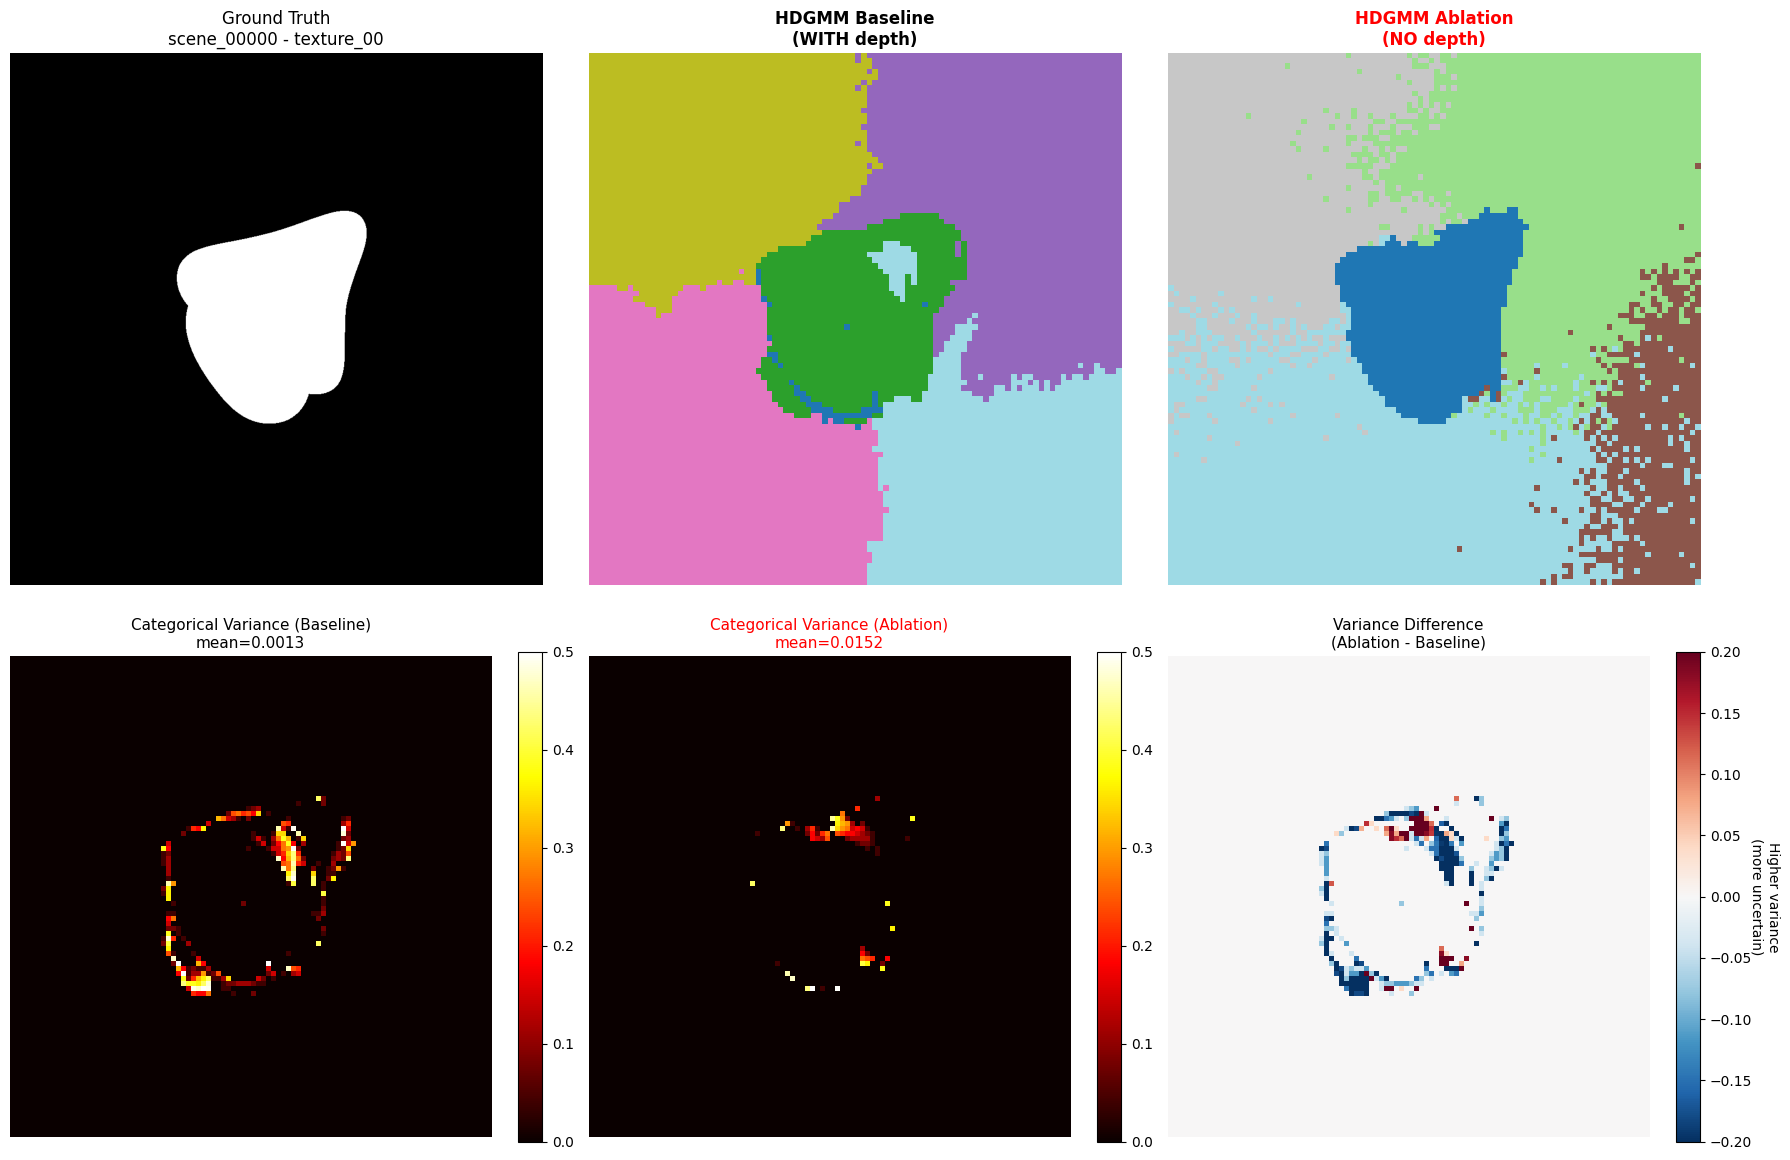


Ablation comparison visualization saved to /home/esli/GenParticles_neural_stimulus/analysis_results_ablation_no_depth/ablation_comparison_scene_00000_texture_00.png


In [ ]:
# Visualization: Example segmentation comparison (Ablation focus)

if existing_combinations:
    scene, texture = existing_combinations[0]
    frame_idx = 0
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Ground truth
    true_mask = load_ground_truth_mask(scene, frame_idx)
    if true_mask is not None:
        axes[0, 0].imshow(true_mask, cmap='gray')
        axes[0, 0].set_title(f'Ground Truth\n{scene} - {texture}', fontsize=12)
        axes[0, 0].axis('off')
    
    # HDGMM Baseline segmentation
    hdgmm_baseline_mask = load_hdgmm_mask(scene, texture, frame_idx, num_runs=1, use_baseline=True)
    if hdgmm_baseline_mask is not None:
        axes[0, 1].imshow(hdgmm_baseline_mask, cmap='tab20')
        axes[0, 1].set_title('HDGMM Baseline\n(WITH depth)', fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
    
    # HDGMM Ablation segmentation
    hdgmm_ablation_mask = load_hdgmm_mask(scene, texture, frame_idx, num_runs=1, use_baseline=False)
    if hdgmm_ablation_mask is not None:
        axes[0, 2].imshow(hdgmm_ablation_mask, cmap='tab20')
        axes[0, 2].set_title('HDGMM Ablation\n(NO depth)', fontsize=12, fontweight='bold', color='red')
        axes[0, 2].axis('off')
    
    # Categorical variance - Baseline
    pixel_vars_baseline, mean_var_baseline, spatial_var_baseline = analyze_categorical_variance(
        scene, texture, 0, True, use_baseline=True)
    if pixel_vars_baseline is not None:
        im = axes[1, 0].imshow(pixel_vars_baseline[frame_idx], cmap='hot', vmin=0, vmax=0.5)
        axes[1, 0].set_title(f'Categorical Variance (Baseline)\nmean={mean_var_baseline:.4f}', fontsize=11)
        axes[1, 0].axis('off')
        plt.colorbar(im, ax=axes[1, 0], fraction=0.046)
    
    # Categorical variance - Ablation
    pixel_vars_ablation, mean_var_ablation, spatial_var_ablation = analyze_categorical_variance(
        scene, texture, 0, True, use_baseline=False)
    if pixel_vars_ablation is not None:
        im = axes[1, 1].imshow(pixel_vars_ablation[frame_idx], cmap='hot', vmin=0, vmax=0.5)
        axes[1, 1].set_title(f'Categorical Variance (Ablation)\nmean={mean_var_ablation:.4f}', fontsize=11, color='red')
        axes[1, 1].axis('off')
        plt.colorbar(im, ax=axes[1, 1], fraction=0.046)
    
    # Variance difference map
    if pixel_vars_baseline is not None and pixel_vars_ablation is not None:
        var_diff = pixel_vars_ablation[frame_idx] - pixel_vars_baseline[frame_idx]
        im = axes[1, 2].imshow(var_diff, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
        axes[1, 2].set_title(f'Variance Difference\n(Ablation - Baseline)', fontsize=11)
        axes[1, 2].axis('off')
        cbar = plt.colorbar(im, ax=axes[1, 2], fraction=0.046)
        cbar.set_label('Higher variance\n(more uncertain)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'ablation_comparison_{scene}_{texture}.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nAblation comparison visualization saved to {OUTPUT_DIR}/ablation_comparison_{scene}_{texture}.png")